# __Census Data Modelling Practice For Adelaide CBD / North Adelaide__

Goal is to put census data into the node network. tables-formatted contains Mesh Block codes with method of transport counts and also DZN codes for people's POW with counts of different occupations.

In [ ]:
import sys
!{sys.executable} -m pip install --quiet osmnx networkx matplotlib

In [2]:
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas as gpd

ox.settings.log_console = True
ox.settings.use_cache = True

Matplotlib is building the font cache; this may take a moment.


__*Define Area using OSM's relation for the entire Central Adelaide LGA 3093825*__

In [3]:
gdf_boundary = ox.geocode_to_gdf("R3093825", by_osmid=True)
polygon = gdf_boundary.geometry.iloc[0]

G = ox.graph_from_polygon(polygon, network_type="bike")
print(f"Nodes: {len(G.nodes)}. Edges: {len(G.edges)}")

Nodes: 3687. Edges: 8251


In [4]:
print(gdf_boundary.display_name[0])

Adelaide City Council, South Australia, Australia


# Adelaide City Node Network

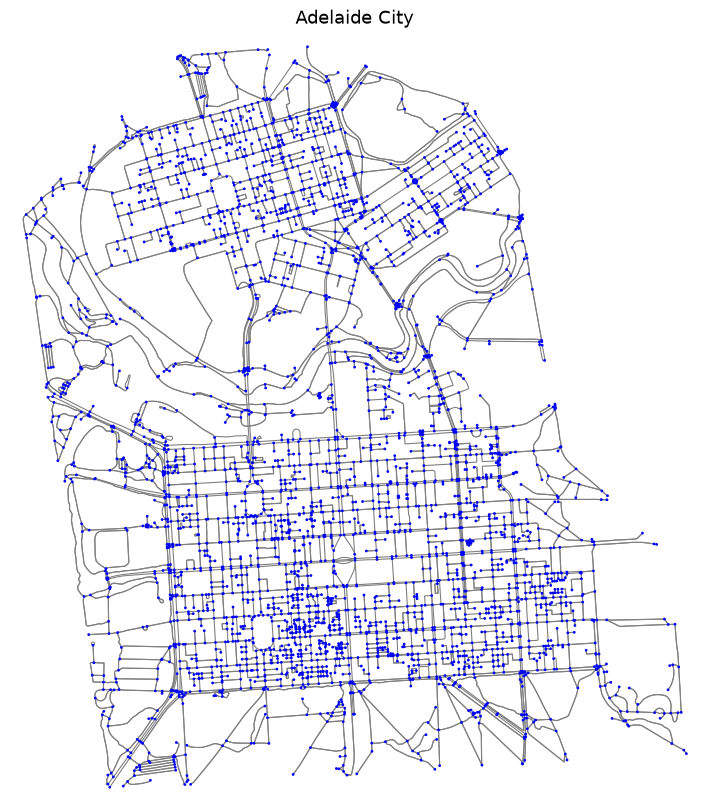

In [15]:
fig, ax = ox.plot_graph(
    G,
    node_size=4,
    node_color="blue",
    node_zorder=3,
    edge_color="gray",
    edge_linewidth=0.8,
    bgcolor="white",
    figsize=(10, 10),
    show=False,
    close=False,
)
ax.set_title("Adelaide City", fontsize=13)
plt.show()

__*Load in ALL of the mesh blocks*__

In [6]:
all_mesh_blocks = gpd.read_file("../australia-mesh-blocks-raw/MB_2021_AUST_GDA2020.shp")

__*match crs and clip mesh_blocks*__

In [10]:
gdf_boundary_crs = gdf_boundary.to_crs(all_mesh_blocks.crs)
mesh_blocks_adl = gpd.clip(all_mesh_blocks, gdf_boundary_crs)

*Test mesh block counts*

In [ ]:
print('All count: ', len(all_mesh_blocks))
print('Adelaide count: ', len(mesh_blocks_adl))

__*Add mesh block number to each node in the graph*__

In [ ]:
# i dont know

# __Importing CSV Data Into the Project__

I have two tables to practice with:

`tables-formatted/transport-mode-MB` gives the count of each preferred mode of transport for each mesh block in the adelaide city zone. The mesh blocks are by usual residence.

`tables-formatted/POW-occupation-DZN` gives the count of each occupation type for each destination zone. The destination zone of each data point is that person's place of work.

In [ ]:
import csv
